In [21]:
import os
import json
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset, random_split
from PIL import Image

from gap.classifiers import ScalableResNetLite
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer
from gap.data import OxfordPetDataset

In [22]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models"

metadata_path = os.path.join(RUN_DIR, "pets_binary_metadata.json")
weights_path = os.path.join(RUN_DIR, "pets_binary_classifier.pth")

with open(metadata_path, "r") as f:
    best_model = json.load(f)

best_config = best_model["model_config"]
print(f"Loaded config: {best_config}")

Using device: mps
Loaded config: {'lr': 0.000108995648041844, 'channels': 64, 'depth': 6, 'optimizer': 'sgd', 'weight_decay': 0.0001}


In [23]:
# Instantiate the model using the weights and metadata loaded
trained_model = ScalableResNetLite(
    num_classes=2, channels=best_config["channels"], depth=best_config["depth"]
).to(device)

trained_model.load_state_dict(
    torch.load(weights_path, map_location=device, weights_only=True)
)
trained_model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [24]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),

    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
    ),
])

transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),

    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
    ),
])

root = "../oxford-iiit-pet/images"

full_dataset = OxfordPetDataset(root, binary=True, transform=transform_train)
num_classes = len(full_dataset.classes)
print("Classes:", num_classes)

Classes: 2


In [ ]:
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42) 
)

# Validation/test use deterministic transforms
val_dataset.dataset.transform = transform_test
test_dataset.dataset.transform = transform_test

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

Train: 5173 Val: 1108 Test: 1109


In [ ]:
# this is for normalizing the data loaded from cifar10. The data is testdata (test_batch I believe)
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

root="../oxford-iiit-pet"


# There are 10000 test samples to choose from
test_subset = Subset(test_data, range(1000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Data loaded successfully! Ready for adversarial generation.


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Next steps: **Prepare the data for purification**
- Perform inference on the test data loaded with the loaded classification model.
- Identify all of the samples that were classified correctly and take that subset of samples.
- Generate adversarial data examples for all of those correctly classified samples from the test data. Use both PGD and FGSM.

In [6]:
attacker = AdversarialAttacker(trained_model, device)

clean_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...


In [7]:
fgsm_loader = attacker.generate_adversarial_dataset(
    clean_loader, attack_type="fgsm", epsilon=8 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    clean_loader, attack_type="pgd", epsilon=8 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [8]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/pets_binary_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/pets_binary_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [9]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/pets_binary_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/pets_binary_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

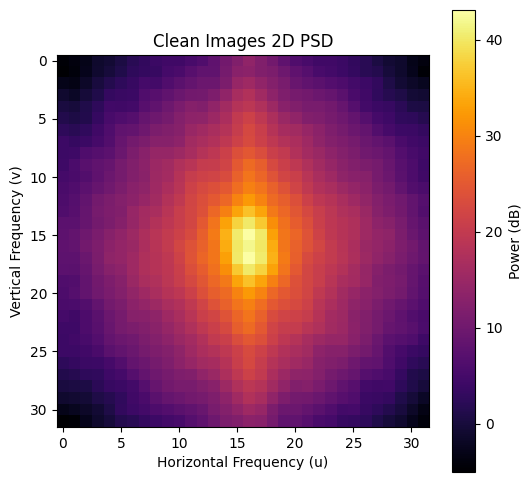

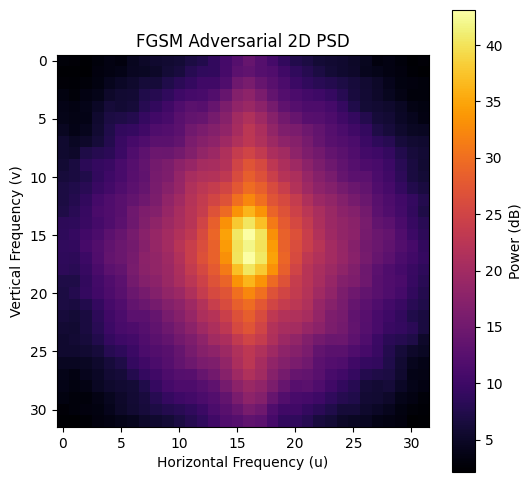

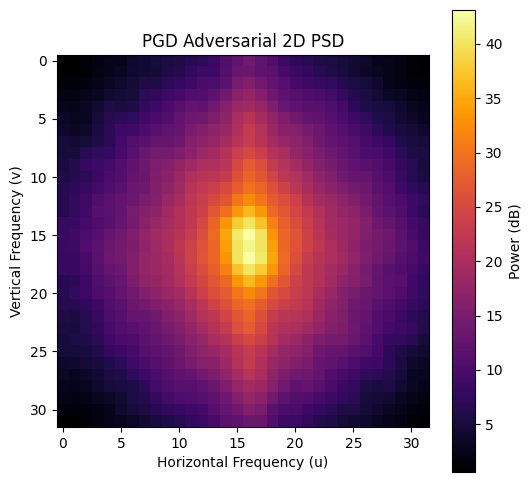

In [10]:
# Extract the underlying image tensors for plotting
clean_images, _ = clean_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(32, 32), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(clean_images, title="Clean Images 2D PSD")
analyzer.plot_2d(fgsm_images, title="FGSM Adversarial 2D PSD")
analyzer.plot_2d(pgd_images, title="PGD Adversarial 2D PSD")

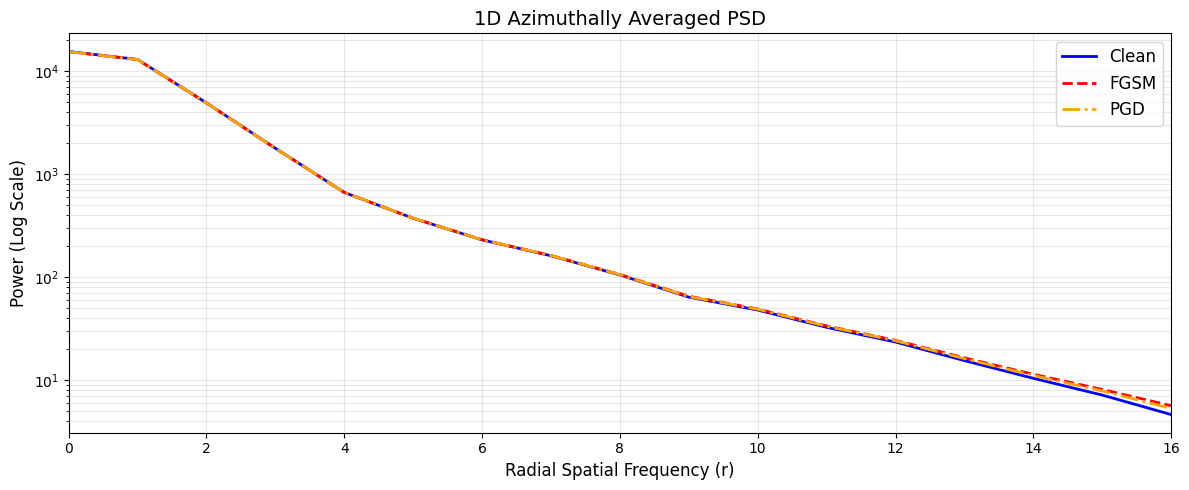

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:186: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=100)


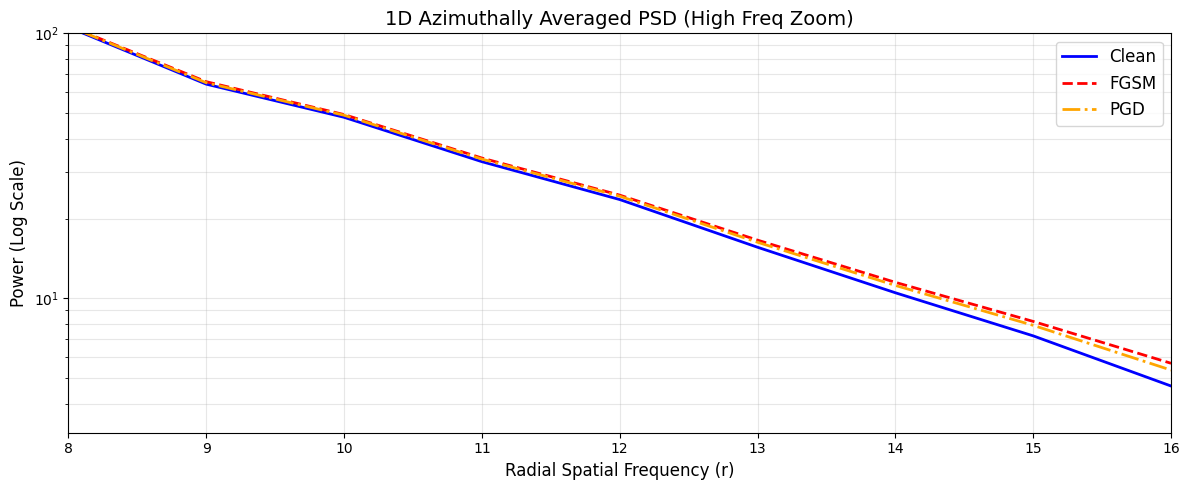

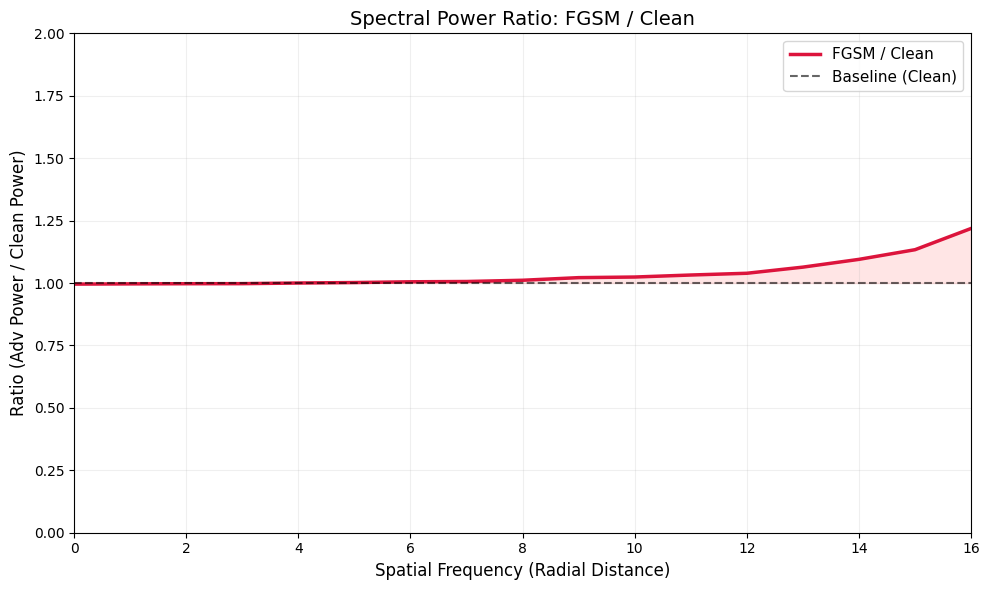

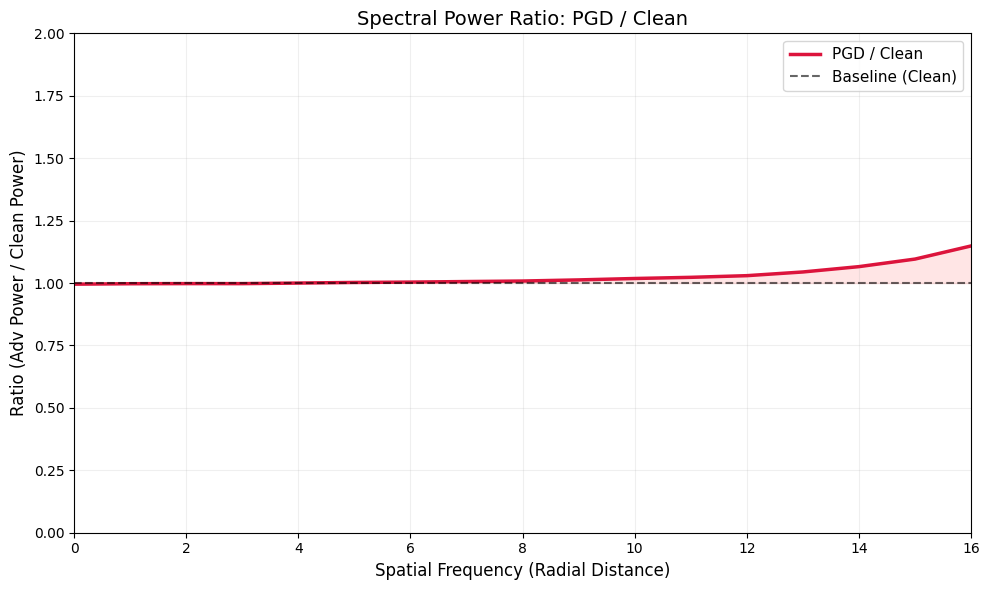

In [11]:
# Compare their 1D profiles on the same plot
analyzer.plot_1d({"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images})

# Compare their 1D profiles on the same plot
analyzer.plot_1d(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}, zoom_high_freq=True
)


analyzer.plot_1d_ratio(clean_images, fgsm_images, label="FGSM / Clean")
analyzer.plot_1d_ratio(clean_images, pgd_images, label="PGD / Clean")

Dataset    | Low-Freq Power (dB)  | High-Freq Power (dB)
-------------------------------------------------------
Clean      | 31.5307              | 13.4941             
FGSM       | 31.5306              | 13.7842             
PGD        | 31.5305              | 13.7002             


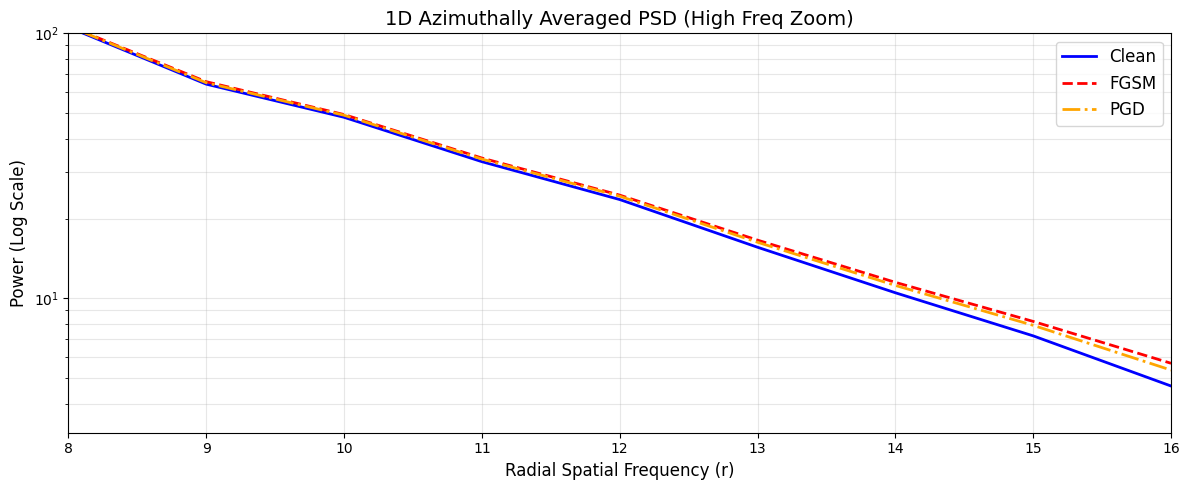

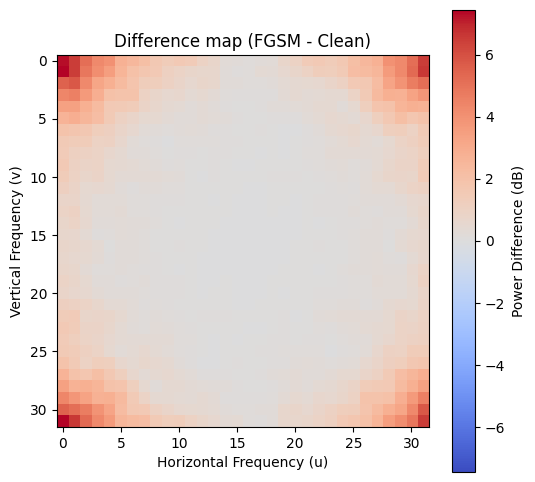

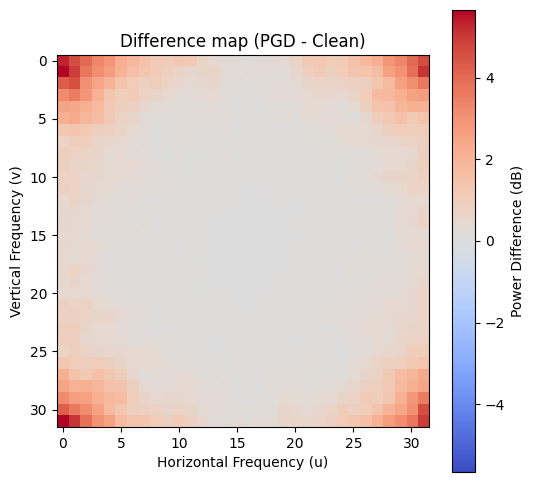

In [12]:
analyzer.print_spectral_stats(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}
)

analyzer.plot_1d(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}, zoom_high_freq=True
)

analyzer.plot_2d_difference(
    images_base=clean_images,
    images_adv=fgsm_images,
    title="Difference map (FGSM - Clean)",
)
analyzer.plot_2d_difference(
    images_base=clean_images,
    images_adv=pgd_images,
    title="Difference map (PGD - Clean)",
)